<a href="https://colab.research.google.com/github/hannahch-beep/Customer-Perception-Text-Mining-Analysis-Southwest-Airlines/blob/main/Southwest_r_Airline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip3 install praw
import praw
import random
import re

import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)


Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
pip install pyLDAvis

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
# Log In to App:
reddit = praw.Reddit(client_id='LchMksVUmRUeyg', client_secret='gb1XyXX-r0ycV9KKFM-ujFVNOogO_w', user_agent='Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3')


## Data Scraping

In [ ]:

# Get the "Airlines" subreddit
subreddit = reddit.subreddit('Travel')


In [ ]:

# Search for comments containing the word "booking"
search_results = subreddit.search("Airlines", limit=100)


In [ ]:
# Initialize an empty list to store the comments
comments = []

# Loop through the search results and append the comments to the list
for submission in search_results:
    comments.append(submission.selftext)
    submission.comments.replace_more(limit=None)
    for comment in submission.comments:
        comments.append(comment.body)


It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/l

In [ ]:
comments[1]

"Any usa airline is safe. You are much more likely to die in a car crash or heart disease in the us. If you fly a budget airline just keep in mind you are basically cattle. It's like grey hound busses. It'll get you there in one peice and it's cheap. Don't expect much and you'll be fine."

In [ ]:
len(comments)

1949

In [ ]:
import pandas as pd

# Convert the cleaned comments to a Pandas dataframe
df = pd.DataFrame(comments, columns=['comment'])

# Print the dataframe
print(df)

                                                comment
0     Apparently overnight Spirit airlines has a cho...
1     Any usa airline is safe. You are much more lik...
2     For a 90 minute fight, and if you’re aware of ...
3     Like others have said, they're safe and a no f...
4     I flew spirit just over a month ago and it was...
...                                                 ...
1944  Hello everyone, \n\nSo I was flying from Barce...
1945  That sucks, but it's no surprise. The pandemic...
1946  If you're planning to fly with Turkish Airline...
1947  Agreed. Turkish Airlines has the worst custome...
1948  Their customer service phone representatives a...

[1949 rows x 1 columns]


In [ ]:
# determining the name of the file
file_name = 'comments.xlsx'

# saving the excel
df.to_excel(file_name)

from google.colab import files
files.download("comments.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Cleaning Comments

In [ ]:
len(comments)

1949

In [ ]:
comments[1]

"Any usa airline is safe. You are much more likely to die in a car crash or heart disease in the us. If you fly a budget airline just keep in mind you are basically cattle. It's like grey hound busses. It'll get you there in one peice and it's cheap. Don't expect much and you'll be fine."

In [ ]:
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

In [ ]:
# Get Rid of '*', '~', '$', '%', '•', '-'
# * and $ are Metacharacters so need to be escaped using '\'
cleaned = []

for i in comments:
  cleaned.append(re.sub('\*|\$|~|,|%|<|>|-|€|\•','',i))

In [ ]:
for i in cleaned:
  print(i)
len(cleaned)

Apparently overnight Spirit airlines has a chokehold on my local airport. They're the only ones offering a direct flight to my destination (1 hour 30 min flight)

So how bad is it really? I'm okay with no snacks and no carry on I'm worried about reliability and safety. Has it cleaned up at all since it merged with JetBlue?

Edit: Apparently they haven't merged with JetBlue yet (if they will at all.

Edit: Y'all scared me and I went with a different airline. I still might try them on another trip that isn't on a time crunch.
Any usa airline is safe. You are much more likely to die in a car crash or heart disease in the us. If you fly a budget airline just keep in mind you are basically cattle. It's like grey hound busses. It'll get you there in one peice and it's cheap. Don't expect much and you'll be fine.
For a 90 minute fight and if you’re aware of the baggage rules so no surprise charges it’s perfectly fine. From a safety perspective also completely safe
Like others have said they'r

1949

## Tokenization

In [ ]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [ ]:
import nltk
from nltk.tokenize import word_tokenize

# Tokenize each element of the cleaned array
cleaned_tokens = [nltk.word_tokenize(text) for text in cleaned]

print(cleaned_tokens)

[['Apparently', 'overnight', 'Spirit', 'airlines', 'has', 'a', 'chokehold', 'on', 'my', 'local', 'airport', '.', 'They', "'re", 'the', 'only', 'ones', 'offering', 'a', 'direct', 'flight', 'to', 'my', 'destination', '(', '1', 'hour', '30', 'min', 'flight', ')', 'So', 'how', 'bad', 'is', 'it', 'really', '?', 'I', "'m", 'okay', 'with', 'no', 'snacks', 'and', 'no', 'carry', 'on', 'I', "'m", 'worried', 'about', 'reliability', 'and', 'safety', '.', 'Has', 'it', 'cleaned', 'up', 'at', 'all', 'since', 'it', 'merged', 'with', 'JetBlue', '?', 'Edit', ':', 'Apparently', 'they', 'have', "n't", 'merged', 'with', 'JetBlue', 'yet', '(', 'if', 'they', 'will', 'at', 'all', '.', 'Edit', ':', "Y'all", 'scared', 'me', 'and', 'I', 'went', 'with', 'a', 'different', 'airline', '.', 'I', 'still', 'might', 'try', 'them', 'on', 'another', 'trip', 'that', 'is', "n't", 'on', 'a', 'time', 'crunch', '.'], ['Any', 'usa', 'airline', 'is', 'safe', '.', 'You', 'are', 'much', 'more', 'likely', 'to', 'die', 'in', 'a', 'c

## Remove Stopwords

In [ ]:
import nltk
from nltk.corpus import stopwords

# Download the stopwords corpus if not already downloaded
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
# Get the English stopwords
stop_words = set(stopwords.words('english'))

stop_words.update(['.', '?', '!',"’",'&',',','-','"',':','[',']',"n't","–",')','(',"'re","'s"])  # add multiple items using update method

# Define a function to remove stopwords from a list of tokens
def remove_stopwords(cleaned_tokens):
    return [token for token in cleaned_tokens if token.lower() not in stop_words]


In [ ]:
# Remove stopwords from each element in the tokenized data
cleaned_tokens = [remove_stopwords(tokens) for tokens in cleaned_tokens]

In [ ]:
cleaned_tokens

[['Apparently',
  'overnight',
  'Spirit',
  'airlines',
  'chokehold',
  'local',
  'airport',
  'ones',
  'offering',
  'direct',
  'flight',
  'destination',
  '1',
  'hour',
  '30',
  'min',
  'flight',
  'bad',
  'really',
  "'m",
  'okay',
  'snacks',
  'carry',
  "'m",
  'worried',
  'reliability',
  'safety',
  'cleaned',
  'since',
  'merged',
  'JetBlue',
  'Edit',
  'Apparently',
  'merged',
  'JetBlue',
  'yet',
  'Edit',
  "Y'all",
  'scared',
  'went',
  'different',
  'airline',
  'still',
  'might',
  'try',
  'another',
  'trip',
  'time',
  'crunch'],
 ['usa',
  'airline',
  'safe',
  'much',
  'likely',
  'die',
  'car',
  'crash',
  'heart',
  'disease',
  'us',
  'fly',
  'budget',
  'airline',
  'keep',
  'mind',
  'basically',
  'cattle',
  'like',
  'grey',
  'hound',
  'busses',
  "'ll",
  'get',
  'one',
  'peice',
  'cheap',
  'expect',
  'much',
  "'ll",
  'fine'],
 ['90',
  'minute',
  'fight',
  'aware',
  'baggage',
  'rules',
  'surprise',
  'charges',
 

## Topic Modeling

In [ ]:
import gensim

# Create a dictionary from the tokenized data
dictionary = gensim.corpora.Dictionary(cleaned_tokens)

In [ ]:

# Create a document-term matrix from the tokenized data
doc_term_matrix = [dictionary.doc2bow(doc) for doc in cleaned_tokens]

In [ ]:
# Define the number of topics to be extracted
num_topics = 10

In [ ]:
# Create an LDA model
lda_model = gensim.models.ldamodel.LdaModel(doc_term_matrix, num_topics=num_topics, id2word=dictionary, passes=10)

# Print the topics and their top keywords
for idx, topic in lda_model.print_topics(-1):
    print('Topic: {} \nKeywords: {}'.format(idx, topic))

Topic: 0 
Keywords: 0.012*"airlines" + 0.010*"fly" + 0.007*"Delta" + 0.007*"American" + 0.006*"service" + 0.005*"airline" + 0.005*"like" + 0.005*"pay" + 0.005*"flying" + 0.005*"US"
Topic: 1 
Keywords: 0.011*"flight" + 0.011*"airline" + 0.011*"bag" + 0.007*"would" + 0.007*"gate" + 0.006*"get" + 0.006*"one" + 0.006*"people" + 0.006*"bags" + 0.005*"fit"
Topic: 2 
Keywords: 0.017*"flight" + 0.007*"last" + 0.006*"flying" + 0.005*"flights" + 0.005*"flew" + 0.005*"get" + 0.005*"time" + 0.005*"free" + 0.005*"good" + 0.005*"times"
Topic: 3 
Keywords: 0.009*"airline" + 0.008*"United" + 0.007*"class" + 0.007*"flight" + 0.006*"food" + 0.006*"good" + 0.006*"experience" + 0.005*"flights" + 0.005*"service" + 0.005*"Airlines"
Topic: 4 
Keywords: 0.022*"flight" + 0.009*"time" + 0.009*"get" + 0.008*"like" + 0.006*"airlines" + 0.006*"fly" + 0.006*"bag" + 0.006*"airport" + 0.005*"would" + 0.005*"go"
Topic: 5 
Keywords: 0.016*"flight" + 0.011*"name" + 0.007*"seat" + 0.007*"airline" + 0.007*"get" + 0.007*"A

In [ ]:
!pip install pyldavis

import pyLDAvis
import pyLDAvis.gensim_models as gensimvis


Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
# Create the visualization
vis_data = gensimvis.prepare(lda_model, doc_term_matrix, dictionary)

# Display the visualization
pyLDAvis.display(vis_data)

In [ ]:

import matplotlib.pyplot as plt

# Set the topic order to display only Topic 8
topic_order = [8]

# Take a screenshot of the visualization
plt.savefig('pyLDAvis.png')

# Download the screenshot
from google.colab import files
files.download('pyLDAvis.png')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<Figure size 640x480 with 0 Axes>

In [ ]:
from gensim.models.coherencemodel import CoherenceModel

# Define the coherence measure to use (c_v)
coherence_model = CoherenceModel(model=lda_model, texts=cleaned_tokens, dictionary=dictionary, coherence='c_v')

# Compute the coherence score
coherence_score = coherence_model.get_coherence()

print("Coherence Score:", coherence_score)


Coherence Score: 0.4125960378815156


## Relevant Comments

In [ ]:
from gensim import corpora

# Create a Bag of Words representation of the tokenized data
dictionary = corpora.Dictionary(cleaned_tokens)
corpus = [dictionary.doc2bow(text) for text in cleaned_tokens]


In [ ]:
# Get the most representative comment for each topic
def get_most_representative_comments(lda_model, corpus, texts, num_comments=1):
    topic_reprs = []
    for i, topic in lda_model.show_topics(formatted=False):
        topic_reprs.append((i, [word[0] for word in topic], []))
    for i, doc in enumerate(corpus):
        topic_scores = lda_model.get_document_topics(doc)
        top_topic = max(topic_scores, key=lambda x: x[1])[0]
        topic_reprs[top_topic][2].append(texts[i])
    return [(i, words, comments[:num_comments]) for i, words, comments in topic_reprs]

# Print the most representative comments for each topic
topic_reprs = get_most_representative_comments(lda_model, corpus, cleaned_tokens)
for i, words, comments in topic_reprs:
    print(f"Topic {i+1}: {' '.join(words)}")
    for comment in comments:
        print(comment)
    print("\n")

Topic 1: airlines fly Delta American service airline like pay flying US
['shit', 'spirit', 'well', 'afford', 'airlines', 'thats', 'like', 'Crate', 'Barrel', 'people', 'shitting', 'IKEA', 'sometimes', 'cheapest', 'option', 'option', 'Dont', 'let', 'news', 'drive', 'mind', 'Anxious', 'perfectly', 'good', 'airline', 'really', 'dont', 'bring', 'checkin', 'baggage', 'buy', 'extras', 'since', 'base', 'fare', 'one', 'cheapest', 'sometimes', 'route', 'Thats', 'shines']


Topic 2: flight airline bag would gate get one people bags fit
['bad', 'Feels', 'like', 'school', 'bus', 'ride', 'high', 'school', 'though']


Topic 3: flight last flying flights flew get time free good times
['safe', 'reasonably', 'reliable']


Topic 4: airline United class flight food good experience flights service Airlines
['flew', 'spirit', 'month', 'ago', 'fine', 'Everything', 'went', 'smoothly', 'time', 'FAs', 'really', 'nice']


Topic 5: flight time get like airlines fly bag airport would go
['90', 'min', 'flight', 'ha

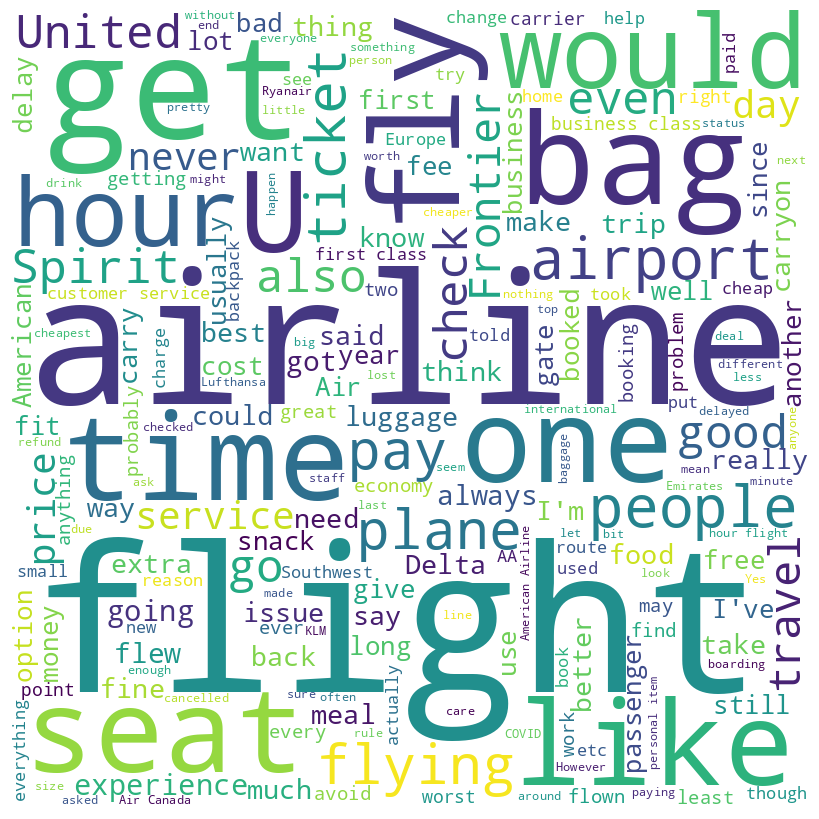

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all the cleaned comments into a single string
all_text = ' '.join(cleaned)

# Create a WordCloud object
wordcloud = WordCloud(width=800, height=800, background_color='white', stopwords=stop_words, min_font_size=10).generate(all_text)

# Display the wordcloud
plt.figure(figsize=(8, 8), facecolor=None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()


In [ ]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Download the VADER lexicon if not already downloaded
nltk.download('vader_lexicon')

# Initialize the VADER sentiment analyzer
analyzer = SentimentIntensityAnalyzer()

# Define a function to get the sentiment scores for a given comment
def get_sentiment_scores(comment):
    scores = analyzer.polarity_scores(comment)
    return scores

# Add a new column to the dataframe with the sentiment scores for each comment
df['sentiment_scores'] = df['comment'].apply(get_sentiment_scores)

# Extract the positive, negative, and neutral scores for each comment
df['positive_score'] = df['sentiment_scores'].apply(lambda x: x['pos'])
df['negative_score'] = df['sentiment_scores'].apply(lambda x: x['neg'])
df['neutral_score'] = df['sentiment_scores'].apply(lambda x: x['neu'])

# Compute the overall sentiment score for each comment
df['overall_score'] = df['sentiment_scores'].apply(lambda x: x['compound'])

# Print the updated dataframe
print(df)


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


                                                comment   
0     Apparently overnight Spirit airlines has a cho...  \
1     Any usa airline is safe. You are much more lik...   
2     For a 90 minute fight, and if you’re aware of ...   
3     Like others have said, they're safe and a no f...   
4     I flew spirit just over a month ago and it was...   
...                                                 ...   
1944  Hello everyone, \n\nSo I was flying from Barce...   
1945  That sucks, but it's no surprise. The pandemic...   
1946  If you're planning to fly with Turkish Airline...   
1947  Agreed. Turkish Airlines has the worst custome...   
1948  Their customer service phone representatives a...   

                                       sentiment_scores  positive_score   
0     {'neg': 0.132, 'neu': 0.803, 'pos': 0.065, 'co...           0.065  \
1     {'neg': 0.105, 'neu': 0.766, 'pos': 0.129, 'co...           0.129   
2     {'neg': 0.2, 'neu': 0.434, 'pos': 0.367, 'comp...           

In [ ]:
df.head()

,comment,sentiment_scores,positive_score,negative_score,neutral_score,overall_score
0,Apparently overnight Spirit airlines has a cho...,"{'neg': 0.132, 'neu': 0.803, 'pos': 0.065, 'co...",0.065,0.132,0.803,-0.7882
1,Any usa airline is safe. You are much more lik...,"{'neg': 0.105, 'neu': 0.766, 'pos': 0.129, 'co...",0.129,0.105,0.766,-0.1189
2,"For a 90 minute fight, and if you’re aware of ...","{'neg': 0.2, 'neu': 0.434, 'pos': 0.367, 'comp...",0.367,0.200,0.434,0.7609
3,"Like others have said, they're safe and a no f...","{'neg': 0.098, 'neu': 0.806, 'pos': 0.095, 'co...",0.095,0.098,0.806,-0.0644
4,I flew spirit just over a month ago and it was...,"{'neg': 0.0, 'neu': 0.742, 'pos': 0.258, 'comp...",0.258,0.000,0.742,0.6801


In [ ]:
df['label'] = "neutral"
df.loc[df['overall_score'] > 0.2, 'label'] = "positive"
df.loc[df['overall_score'] < -0.2, 'label'] = "negative"
df.head(50)

,comment,sentiment_scores,positive_score,negative_score,neutral_score,overall_score,label
0,Apparently overnight Spirit airlines has a cho...,"{'neg': 0.132, 'neu': 0.803, 'pos': 0.065, 'co...",0.065,0.132,0.803,-0.7882,negative
1,Any usa airline is safe. You are much more lik...,"{'neg': 0.105, 'neu': 0.766, 'pos': 0.129, 'co...",0.129,0.105,0.766,-0.1189,neutral
2,"For a 90 minute fight, and if you’re aware of ...","{'neg': 0.2, 'neu': 0.434, 'pos': 0.367, 'comp...",0.367,0.200,0.434,0.7609,positive
3,"Like others have said, they're safe and a no f...","{'neg': 0.098, 'neu': 0.806, 'pos': 0.095, 'co...",0.095,0.098,0.806,-0.0644,neutral
4,I flew spirit just over a month ago and it was...,"{'neg': 0.0, 'neu': 0.742, 'pos': 0.258, 'comp...",0.258,0.000,0.742,0.6801,positive
5,I don’t know. They cancelled the flight I book...,"{'neg': 0.1, 'neu': 0.9, 'pos': 0.0, 'compound...",0.000,0.100,0.900,-0.2500,negative
6,Not bad. Feels like a school bus ride in high ...,"{'neg': 0.151, 'neu': 0.645, 'pos': 0.204, 'co...",0.204,0.151,0.645,0.1877,neutral
7,Its only 1.5 hours and you will be fine. Just ...,"{'neg': 0.0, 'neu': 0.904, 'pos': 0.096, 'comp...",0.096,0.000,0.904,0.2023,positive
8,"US carriers won’t fall out of the sky, by Spir...","{'neg': 0.187, 'neu': 0.725, 'pos': 0.088, 'co...",0.088,0.187,0.725,-0.4404,negative
9,My husband is a captain for Spirit. \n\n100% a...,"{'neg': 0.069, 'neu': 0.785, 'pos': 0.147, 'co...",0.147,0.069,0.785,0.5705,positive


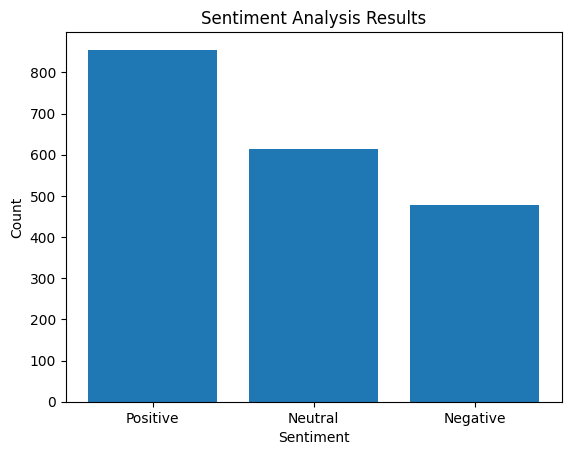

In [ ]:
import matplotlib.pyplot as plt

# Count the number of positive, neutral, and negative comments
positive_count = df[df['label'] == 'positive']['label'].count()
neutral_count = df[df['label'] == 'neutral']['label'].count()
negative_count = df[df['label'] == 'negative']['label'].count()

# Create a bar graph
fig, ax = plt.subplots()
ax.bar(['Positive', 'Neutral', 'Negative'], [positive_count, neutral_count, negative_count])

# Set axis labels and title
ax.set_xlabel('Sentiment')
ax.set_ylabel('Count')
ax.set_title('Sentiment Analysis Results')

# Display the graph
plt.show()


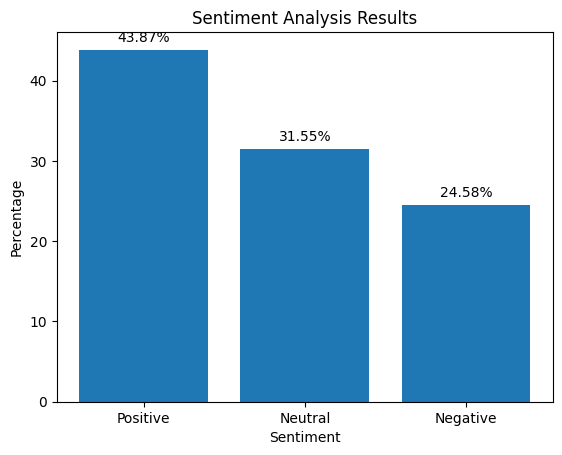

In [ ]:
import matplotlib.pyplot as plt

# Count the number of positive, neutral, and negative comments
positive_count = df[df['label'] == 'positive']['label'].count()
neutral_count = df[df['label'] == 'neutral']['label'].count()
negative_count = df[df['label'] == 'negative']['label'].count()

# Calculate the percentage of positive, neutral, and negative comments
total_count = len(df)
positive_percent = positive_count / total_count * 100
neutral_percent = neutral_count / total_count * 100
negative_percent = negative_count / total_count * 100

# Create a bar graph
fig, ax = plt.subplots()
ax.bar(['Positive', 'Neutral', 'Negative'], [positive_percent, neutral_percent, negative_percent])

# Label the bars with their respective percentages
for i, v in enumerate([positive_percent, neutral_percent, negative_percent]):
    ax.text(i, v + 1, f'{v:.2f}%', ha='center')

# Set axis labels and title
ax.set_xlabel('Sentiment')
ax.set_ylabel('Percentage')
ax.set_title('Sentiment Analysis Results')

# Display the graph
plt.show()


In [ ]:
import plotly.express as px

fig = px.histogram(df, x="overall_score", color = "label")
fig.show()

In [ ]:
!pip install -U kaleido


Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
import plotly.io as pio

# Save as PNG file
pio.write_image(fig, file='histogram.png')

## Evaluate the negative Comments

In [ ]:
negative_df = df[df['label'] == 'negative']

negative_df.head()

,comment,sentiment_scores,positive_score,negative_score,neutral_score,overall_score,label
0,Apparently overnight Spirit airlines has a cho...,"{'neg': 0.132, 'neu': 0.803, 'pos': 0.065, 'co...",0.065,0.132,0.803,-0.7882,negative
5,I don’t know. They cancelled the flight I book...,"{'neg': 0.1, 'neu': 0.9, 'pos': 0.0, 'compound...",0.000,0.100,0.900,-0.2500,negative
8,"US carriers won’t fall out of the sky, by Spir...","{'neg': 0.187, 'neu': 0.725, 'pos': 0.088, 'co...",0.088,0.187,0.725,-0.4404,negative
10,"Direct flights are not that bad, seats are ver...","{'neg': 0.165, 'neu': 0.738, 'pos': 0.097, 'co...",0.097,0.165,0.738,-0.6606,negative
11,> 90 min flight\n\nI hate Spirit but I could s...,"{'neg': 0.207, 'neu': 0.708, 'pos': 0.086, 'co...",0.086,0.207,0.708,-0.8176,negative


In [ ]:

# Tokenize the negative comments
tokens = [word_tokenize(comment.lower()) for comment in negative_df['comment']]


In [ ]:
from nltk.corpus import stopwords

# Define stop words
stop_words = set(stopwords.words('english'))

stop_words.update(['.', '?', '!',"’",'&',',','-','"',':','[',']',"n't","–",')','(',"'re","'s",'*',"'ve",'2'])  # add multiple items using update method

# Remove stop words from tokens
tokens = [[word for word in comment if not word in stop_words] for comment in tokens]


In [ ]:
# Create a dictionary from the tokenized comments
dictionary = corpora.Dictionary(tokens)


# Convert tokenized comments to bag of words format
corpus = [dictionary.doc2bow(token) for token in tokens]

In [ ]:
# Import required libraries
from gensim import corpora, models

# Create dictionary and corpus for negative comments
dictionary = corpora.Dictionary(tokens)
corpus = [dictionary.doc2bow(text) for text in tokens]

# Run LDA model on the negative comments corpus
lda_model = models.ldamodel.LdaModel(corpus=corpus, id2word=dictionary, num_topics=5, passes=10)


In [ ]:

# Visualize the LDA model using pyLDAvis
vis = gensimvis.prepare(lda_model, corpus, dictionary)
pyLDAvis.display(vis)


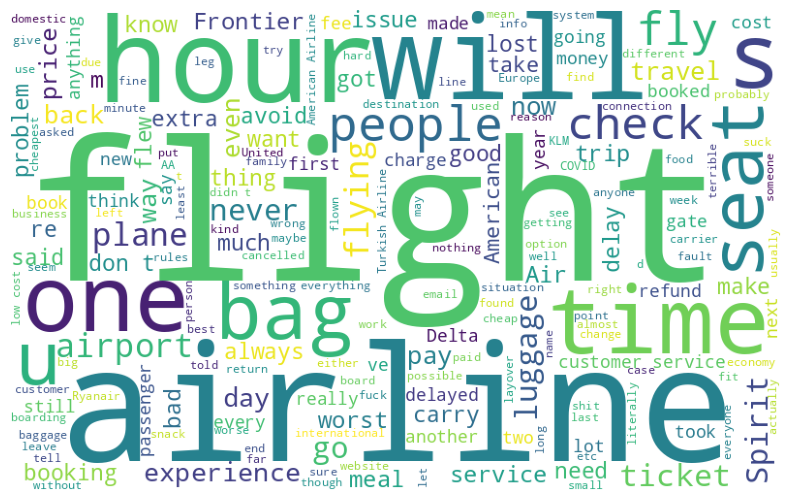

In [ ]:

# Create a wordcloud of the most common negative comment words
negative_words = ' '.join(negative_df['comment'])
wordcloud = WordCloud(width=800, height=500, background_color='white').generate(negative_words)
plt.figure(figsize=(10, 8))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()
